# Credit Card Fraud Detection

XGBoost + SMOTE + Decision Threshold + Feature Importance

In [10]:
!pip install -q xgboost imbalanced-learn kaggle

In [11]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"studentshreya","key":"ab32c33a61688b1e1598037696ce677c"}'}

In [12]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c ieee-fraud-detection
!unzip -q ieee-fraud-detection.zip

100% 118M/118M [00:01<00:00, 70.3MB/s]



In [13]:
!ls

 ieee-fraud-detection.zip   sample_data		    test_transaction.csv
'kaggle (1).json'	    sample_submission.csv   train_identity.csv
 kaggle.json		    test_identity.csv	    train_transaction.csv


In [14]:
!kaggle competitions download -c ieee-fraud-detection
!unzip -o ieee-fraud-detection.zip

ieee-fraud-detection.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  ieee-fraud-detection.zip
  inflating: sample_submission.csv   
  inflating: test_identity.csv       
  inflating: test_transaction.csv    
  inflating: train_identity.csv      
  inflating: train_transaction.csv   


In [15]:
!ls

 ieee-fraud-detection.zip   sample_data		    test_transaction.csv
'kaggle (1).json'	    sample_submission.csv   train_identity.csv
 kaggle.json		    test_identity.csv	    train_transaction.csv


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [17]:
columns = ['TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'isFraud']
df = pd.read_csv('train_transaction.csv', usecols=columns, nrows=150000)
df.shape

(150000, 23)

In [18]:
df['isFraud'].value_counts()

,count
isFraud,
0,146030
1,3970


In [19]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [20]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
pd.Series(y_train_smote).value_counts()

,count
isFraud,
0,116824
1,116824


In [21]:
model = XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42)
model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [22]:
y_prob = model.predict_proba(X_test)[:, 1]
print('Average Precision:', average_precision_score(y_test, y_prob))
print(classification_report(y_test, (y_prob >= 0.5).astype(int)))

Average Precision: 0.49645909403227634
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     29206
           1       0.43      0.53      0.48       794

    accuracy                           0.97     30000
   macro avg       0.71      0.76      0.73     30000
weighted avg       0.97      0.97      0.97     30000



In [23]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1 = 2 * precision * recall / (precision + recall + 1e-10)
best_index = np.argmax(f1[:-1])
best_threshold = thresholds[best_index]
best_threshold

np.float32(0.6458725)

In [24]:
y_pred = (y_prob >= best_threshold).astype(int)
print('Threshold:', best_threshold)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Threshold: 0.6458725
[[28934   272]
 [  441   353]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     29206
           1       0.56      0.44      0.50       794

    accuracy                           0.98     30000
   macro avg       0.77      0.72      0.74     30000
weighted avg       0.97      0.98      0.97     30000



C5     0.157055
C2     0.133770
C11    0.130166
C8     0.088144
C14    0.070339
C9     0.048892
C6     0.046605
C13    0.042527
C1     0.041068
C4     0.030617
dtype: float32


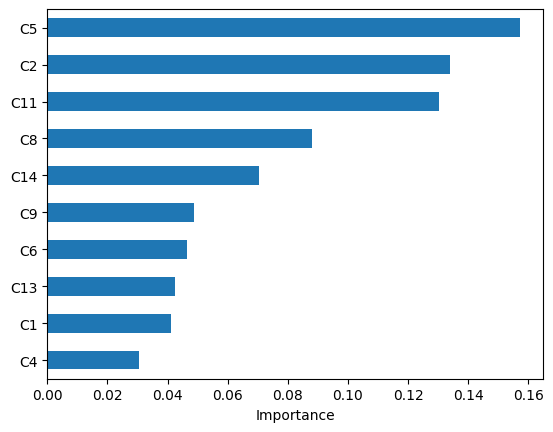

In [25]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
print(importance)
importance.sort_values().plot(kind='barh')
plt.xlabel('Importance')
plt.show()